# Préparation des jeux de données SST pour ML

**Pipeline :** Données brutes → Enrichissement → Filtre/Répartition → Nettoyage → Transformation → Statistiques

**Sources :**
- CSV : `0_Data/0_Raw/ExportSST/export_SSTCAD_20260227/`
- GIS (clusters, U_Puissance) : `0_Data/1_Structured/DATA_GIS_Filtered.parquet`

## 1. Configuration

In [1]:
# Constantes et chemins
import gc
import re
from pathlib import Path
import json
from urllib.request import urlopen
from urllib.error import URLError

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Chemins (depuis 2_Program)
PATH_RAW = Path("0_Data/0_Raw/ExportSST/export_SSTCAD_20260227")
PATH_STRUCTURED = Path("0_Data/1_Structured")
PATH_TRAINING = Path("0_Data/3_training")
PATH_VALIDATION = Path("0_Data/4_Validation")
PATH_TEST = Path("0_Data/5_Test")
PATH_GIS = Path("0_Data/1_Structured/DATA_GIS_Filtered.parquet")
PATH_SST_RAW = PATH_STRUCTURED / "sst_raw.parquet"
PATH_SST_ENRICHED = PATH_STRUCTURED / "sst_enriched.parquet"

# Paramètres
MIN_YEARS_DATA = 1.5
MIN_VALID_RATIO = 0.95
# Agrégation : False = garder PuisCpt à 1 min tel quel, True = agréger à 15 min
AGGREGATION_15MIN = True
FREQ = "15min" if AGGREGATION_15MIN else "1min"  # Pas temporel pour la grille
# Répartition temporelle (depuis la fin des données) :
#   test = 0 à 5 mois + 30 jours (~6 mois)
#   validation = 6 à 11 mois + 30 jours (~6 mois)
#   entrainement = 12 mois et plus
TEST_MONTHS = 5
TEST_EXTRA_DAYS = 30
VAL_MONTHS_MIN = 6
VAL_MONTHS_MAX = 11
VAL_EXTRA_DAYS = 30
TRAIN_MONTHS_MIN = 12

# Météo - Bulle (Suisse)
BULLE_LAT = 46.6175
BULLE_LON = 7.0581

# Créer les dossiers de sortie
for p in [PATH_STRUCTURED, PATH_TRAINING, PATH_VALIDATION, PATH_TEST]:
    p.mkdir(parents=True, exist_ok=True)

## 2. Import des données brutes

Chargement de tous les CSV sans filtre, fusion ni échantillonnage.
Format des colonnes : `EGID.DATATYPE.valeur` et `EGID.DATATYPE.inv` (format long : date, EGID, DATA_TYPE, valeur, inv).

In [2]:
def parse_date(s):
    return pd.to_datetime(s, format="%d/%m/%Y %H:%M", errors="coerce")

def load_raw_csvs(path_raw: Path) -> pd.DataFrame:
    """Charge tous les CSV en un seul DataFrame (format long)."""
    records = []
    csv_files = sorted(path_raw.glob("*.csv"))
    
    for fp in csv_files:
        try:
            df = pd.read_csv(fp, sep=";", encoding="utf-8", on_bad_lines="warn")
        except UnicodeDecodeError:
            df = pd.read_csv(fp, sep=";", encoding="cp1252", on_bad_lines="warn")
        except (pd.errors.EmptyDataError, pd.errors.ParserError):
            print(f"Ignoré (vide/invalide): {fp.name}")
            continue
        
        if df.shape[1] < 3:
            continue
        
        # Colonnes : date, EGID_DATATYPE, inv
        date_col, val_col, inv_col = df.columns[0], df.columns[1], df.columns[2]
        # Extraire EGID et DATA_TYPE du header (ex: 1510837_TempRet)
        parts = val_col.split("_", 1)
        if len(parts) != 2:
            continue
        egid, data_type = parts[0], parts[1]
        
        df = df.copy()
        df["date"] = parse_date(df[date_col])
        df = df.dropna(subset=["date"])
        df["EGID"] = egid
        df["DATA_TYPE"] = data_type
        df["valeur"] = pd.to_numeric(df[val_col], errors="coerce")
        df["inv"] = pd.to_numeric(df[inv_col], errors="coerce").fillna(0)
        records.append(df[["date", "EGID", "DATA_TYPE", "valeur", "inv"]])
    
    if not records:
        return pd.DataFrame()
    return pd.concat(records, ignore_index=True)

df_raw = load_raw_csvs(PATH_RAW)
print(f"Lignes brutes : {len(df_raw):,}")
print(f"EGIDs uniques : {df_raw['EGID'].nunique()}")
print(f"DATA_TYPE : {df_raw['DATA_TYPE'].unique().tolist()}")
df_raw.head(10)

Ignoré (vide/invalide): techant17950_20260227.csv
Lignes brutes : 240,465,534
EGIDs uniques : 369
DATA_TYPE : ['TempRet', 'PuisCpt']


,date,EGID,DATA_TYPE,valeur,inv
0,2026-02-27 13:15:00,235004706,TempRet,28.395556,0
1,2026-02-27 13:00:00,235004706,TempRet,28.413333,0
2,2026-02-27 12:45:00,235004706,TempRet,28.622222,0
3,2026-02-27 12:30:00,235004706,TempRet,29.170000,0
4,2026-02-27 12:15:00,235004706,TempRet,29.283333,0
5,2026-02-27 12:00:00,235004706,TempRet,29.310000,0
6,2026-02-27 11:45:00,235004706,TempRet,29.328889,0
7,2026-02-27 11:30:00,235004706,TempRet,29.367778,0
8,2026-02-27 11:15:00,235004706,TempRet,29.387778,0
9,2026-02-27 11:00:00,235004706,TempRet,29.465556,0


In [3]:
# Export parquet brut
df_raw.to_parquet(PATH_SST_RAW, index=False)
print(f"Exporté : {PATH_SST_RAW}")
del df_raw
import gc; gc.collect()

Exporté : 0_Data\1_Structured\sst_raw.parquet


0

## 3. Enrichissement des données

- Plage temporelle complète au pas configurable (15 min ou 1 min selon `AGGREGATION_15MIN`)
- Données météo (température extérieure) pour toute la plage
- Réexport parquet

In [4]:
if not PATH_SST_RAW.exists():
    raise FileNotFoundError(
        f"Fichier requis absent : {PATH_SST_RAW}. Exécuter la section 2 (Import brut) d'abord."
    )
df_raw = pd.read_parquet(PATH_SST_RAW)

def fetch_temp_ext(start_dt, end_dt):
    """Récupère la température extérieure (Bulle) via Open-Meteo."""
    url = (
        "https://archive-api.open-meteo.com/v1/archive?"
        f"latitude={BULLE_LAT}&longitude={BULLE_LON}"
        f"&start_date={start_dt.strftime('%Y-%m-%d')}&end_date={end_dt.strftime('%Y-%m-%d')}"
        "&hourly=temperature_2m&timezone=UTC"
    )
    try:
        with urlopen(url, timeout=60) as r:
            d = json.loads(r.read().decode())
    except Exception as e:
        print(f"Erreur API météo : {e}")
        return pd.Series(dtype=float)
    h = d.get("hourly", {})
    times = h.get("time", [])
    temps = h.get("temperature_2m", [])
    if not times:
        return pd.Series(dtype=float)
    df = pd.DataFrame({"time": times, "temp": temps})
    df["time"] = pd.to_datetime(df["time"], utc=True)
    df = df.set_index("time")
    rng = pd.date_range(start=start_dt, end=end_dt, freq=FREQ, tz="UTC")
    return df["temp"].reindex(rng, method="ffill").fillna(0.0)

# Plage temporelle globale (FREQ = 15min ou 1min selon AGGREGATION_15MIN)
ts_min = df_raw["date"].min().floor(FREQ)
ts_max = df_raw["date"].max().ceil(FREQ)
full_index = pd.date_range(start=ts_min, end=ts_max, freq=FREQ)

# Données météo (conversion dates en UTC)
def to_utc(ts):
    return pd.Timestamp(ts).tz_localize("Europe/Zurich", ambiguous=True, nonexistent="shift_forward").tz_convert("UTC")
ts_min_utc = to_utc(ts_min)
ts_max_utc = to_utc(ts_max)
temp_ext = fetch_temp_ext(ts_min_utc, ts_max_utc)
full_index_utc = pd.date_range(start=ts_min_utc, end=ts_max_utc, freq=FREQ, tz="UTC")

# DataFrame Dates (UTC) + TempExt
df_dates = pd.DataFrame({"Dates": full_index_utc, "TempExt": temp_ext.values})

# Fusion : convertir dates brutes en UTC, aligner sur FREQ
df_work = df_raw.copy()
df_work["date_15min"] = (
    df_work["date"]
    .dt.tz_localize("Europe/Zurich", ambiguous=True, nonexistent="shift_forward")
    .dt.tz_convert("UTC")
    .dt.floor(FREQ)
)
df_dates_merge = df_dates.rename(columns={"Dates": "date_15min"})
df_enriched = df_work.merge(df_dates_merge, on="date_15min", how="left")
df_enriched["TempExt"] = df_enriched["TempExt"].fillna(0.0)

df_enriched.to_parquet(PATH_SST_ENRICHED, index=False)
print(f"Enrichi : {len(df_enriched):,} lignes, TempExt ajoutée")
head_preview = df_enriched.head()
del df_raw, df_work, df_dates, df_dates_merge, temp_ext, df_enriched
gc.collect()
head_preview

Enrichi : 240,465,534 lignes, TempExt ajoutée


,date,EGID,DATA_TYPE,valeur,inv,date_15min,TempExt
0,2026-02-27 13:15:00,235004706,TempRet,28.395556,0,2026-02-27 12:15:00+00:00,15.4
1,2026-02-27 13:00:00,235004706,TempRet,28.413333,0,2026-02-27 12:00:00+00:00,15.4
2,2026-02-27 12:45:00,235004706,TempRet,28.622222,0,2026-02-27 11:45:00+00:00,15.5
3,2026-02-27 12:30:00,235004706,TempRet,29.170000,0,2026-02-27 11:30:00+00:00,15.5
4,2026-02-27 12:15:00,235004706,TempRet,29.283333,0,2026-02-27 11:15:00+00:00,15.5


## 4. Filtre et répartition

1. Filtrer : EGID avec >1.5 ans de données et >95% valides (inv=0)
2. Répartir par cluster (DATA_GIS_Filtered) et DATA_TYPE
3. Split train (12 mois+) / validation (6-11 mois + 30 j) / test (0-5 mois + 30 j)
4. Export 3_Training, 4_Validation, 5_Test (ex: cluster3_TempRet.parquet)

In [5]:
if not PATH_SST_ENRICHED.exists():
    raise FileNotFoundError(
        f"Fichier requis absent : {PATH_SST_ENRICHED}. Exécuter la section 3 (Enrichissement) d'abord."
    )
df_enriched = pd.read_parquet(PATH_SST_ENRICHED)

# Charger GIS (clusters, U_PUISSANCE)
# U_PUISSANCE : format "40kW", "10kW" -> extraire la valeur numérique
def parse_puissance(x):
    if pd.isna(x):
        return np.nan
    s = str(x).upper().replace(" ", "")
    m = re.search(r"([0-9.]+)\s*K?W?", s)
    return float(m.group(1)) if m else np.nan

df_gis = pd.read_parquet(PATH_GIS)
df_gis["U_NO_EGID"] = df_gis["U_NO_EGID"].astype(str)
egid_to_cluster = df_gis.set_index("U_NO_EGID")["cluster"].to_dict()
# U_PUISSANCE_kW si présent, sinon parser U_PUISSANCE
if "U_PUISSANCE_kW" in df_gis.columns:
    pui_series = df_gis.set_index("U_NO_EGID")["U_PUISSANCE_kW"]
else:
    pui_series = df_gis.set_index("U_NO_EGID")["U_PUISSANCE"].apply(parse_puissance)
egid_to_puissance = pui_series.to_dict()

# Ne garder que les EGIDs présents dans le GIS (clusters 3-6)
valid_egids = set(egid_to_cluster.keys())
df_f = df_enriched[df_enriched["EGID"].astype(str).isin(valid_egids)].copy()

# Aligner sur FREQ (15min ou 1min) pour les stats
df_f["date_15min"] = df_f["date"].dt.tz_localize("Europe/Zurich", ambiguous=True, nonexistent="shift_forward").dt.tz_convert("UTC").dt.floor(FREQ)

# Filtre : >1.5 ans de données et >95% valides (inv=0)
def filter_egids(df):
    df = df.copy()
    df["EGID_str"] = df["EGID"].astype(str)
    grp = df.groupby("EGID_str")
    span = grp["date"].agg(lambda x: (x.max() - x.min()).days / 365.25)
    valid_ratio = grp["inv"].apply(lambda x: (x == 0).mean())
    ok = (span >= MIN_YEARS_DATA) & (valid_ratio >= MIN_VALID_RATIO)
    return ok[ok].index.tolist()

keep_egids = filter_egids(df_f)
df_f = df_f[df_f["EGID"].astype(str).isin(keep_egids)]
print(f"EGIDs après filtre : {len(keep_egids)}")

# Ajouter cluster
df_f["cluster"] = df_f["EGID"].astype(str).map(egid_to_cluster)

EGIDs après filtre : 246


In [6]:
def split_train_val_test(df_egid: pd.DataFrame):
    """
    Répartition temporelle (depuis dmax) :
    - test : 0 à 5 mois + 30 jours
    - validation : 6 à 11 mois + 30 jours
    - entrainement : 12 mois et plus
    """
    dmin = df_egid["date"].min()
    dmax = df_egid["date"].max()
    if (dmax - dmin).days < 365 * 1.5:
        return None, None, None

    # Test : derniers (5 mois + 30 jours)
    test_end = dmax
    test_start = dmax - pd.DateOffset(months=TEST_MONTHS, days=TEST_EXTRA_DAYS)
    # Val : (6 à 11 mois + 30 jours) avant la fin
    val_end = test_start
    val_start = dmax - pd.DateOffset(months=VAL_MONTHS_MAX, days=VAL_EXTRA_DAYS)
    # Train : 12 mois et plus
    train_end = val_start
    train_start = dmin

    if (train_end - train_start).days < 365:
        return None, None, None

    def mask_between(df, start, end):
        return (df["date"] >= start) & (df["date"] <= end)

    return (
        df_egid[mask_between(df_egid, train_start, train_end)],
        df_egid[mask_between(df_egid, val_start, val_end)],
        df_egid[mask_between(df_egid, test_start, test_end)],
    )

def build_split_df(df_part, df_dates_full):
    """Construit un DF avec colonnes Dates, TempExt + colonnes EGID.DATA_TYPE (valeur et .inv)."""
    if df_part.empty:
        return None
    dates_range = pd.date_range(
        df_part["date_15min"].min(), df_part["date_15min"].max(),
        freq=FREQ, tz="UTC"
    )
    # Base : Dates + TempExt
    out = pd.DataFrame({"Dates": dates_range})
    dmin, dmax = dates_range.min(), dates_range.max()
    mask = (df_dates_full["date_15min"] >= dmin) & (df_dates_full["date_15min"] <= dmax)
    temp_map = df_dates_full.loc[mask].set_index("date_15min")["TempExt"]
    out["TempExt"] = out["Dates"].map(lambda t: temp_map.get(t, 0.0))

    # Pivot : valeur et inv par EGID.DATA_TYPE
    df_part = df_part.copy()
    df_part["col"] = df_part["EGID"].astype(str) + "." + df_part["DATA_TYPE"]
    pv = df_part.pivot_table(index="date_15min", columns="col", values="valeur", aggfunc="mean")
    pv_inv = df_part.pivot_table(index="date_15min", columns="col", values="inv", aggfunc="max")
    out = out.set_index("Dates")
    out = out.join(pv.reindex(dates_range), how="left")
    out = out.join(pv_inv.add_suffix(".inv").reindex(dates_range), how="left")
    return out.reset_index()

# Référence Dates + TempExt (depuis enrichi)
df_dates_full = df_enriched[["date_15min", "TempExt"]].drop_duplicates(subset=["date_15min"])

# Par cluster et DATA_TYPE
# Utiliser la plage temporelle COMBINÉE (TempRet + PuisCpt) par EGID pour le split,
# sinon PuisCpt (souvent plus récent) échouerait au seuil 1.5 an
for cluster_id in df_f["cluster"].dropna().unique():
    sub_cluster = df_f[df_f["cluster"] == cluster_id]
    if sub_cluster.empty:
        continue
    egid_splits = {}
    for egid in sub_cluster["EGID"].unique():
        egid_all = sub_cluster[sub_cluster["EGID"] == egid]
        tr, va, te = split_train_val_test(egid_all)
        if tr is not None:
            egid_splits[egid] = {"train": tr, "val": va, "test": te}
    if not egid_splits:
        continue
    for dtype in df_f["DATA_TYPE"].unique():
        splits = {"train": [], "val": [], "test": []}
        for egid, data in egid_splits.items():
            for key in splits:
                part = data[key][data[key]["DATA_TYPE"] == dtype]
                if not part.empty:
                    splits[key].append(part)
        if not splits["train"]:
            continue
        for split_name, path in [("train", PATH_TRAINING), ("val", PATH_VALIDATION), ("test", PATH_TEST)]:
            parts = splits.get(split_name, [])
            if not parts:
                continue
            combined = pd.concat(parts, ignore_index=True)
            out_df = build_split_df(combined, df_dates_full)
            if out_df is not None and not out_df.empty:
                fname = f"cluster{int(cluster_id)}_{dtype}.parquet"
                out_df.to_parquet(path / fname, index=False)
                print(f"  {path.name}/{fname}")

print("Export Filtre/Répartition terminé.")
del df_enriched, df_f, df_dates_full
gc.collect()

  3_training/cluster5_TempRet.parquet
  4_Validation/cluster5_TempRet.parquet
  5_Test/cluster5_TempRet.parquet
  3_training/cluster5_PuisCpt.parquet
  4_Validation/cluster5_PuisCpt.parquet
  5_Test/cluster5_PuisCpt.parquet
  3_training/cluster3_TempRet.parquet
  4_Validation/cluster3_TempRet.parquet
  5_Test/cluster3_TempRet.parquet
  3_training/cluster3_PuisCpt.parquet
  4_Validation/cluster3_PuisCpt.parquet
  5_Test/cluster3_PuisCpt.parquet
  3_training/cluster4_TempRet.parquet
  4_Validation/cluster4_TempRet.parquet
  5_Test/cluster4_TempRet.parquet
  3_training/cluster4_PuisCpt.parquet
  4_Validation/cluster4_PuisCpt.parquet
  5_Test/cluster4_PuisCpt.parquet
  3_training/cluster6_TempRet.parquet
  4_Validation/cluster6_TempRet.parquet
  5_Test/cluster6_TempRet.parquet
  3_training/cluster6_PuisCpt.parquet
  4_Validation/cluster6_PuisCpt.parquet
  5_Test/cluster6_PuisCpt.parquet
Export Filtre/Répartition terminé.


0

## 5. Nettoyage

Pour chaque fichier .parquet du point précédent :
- **PuisCpt** : les valeurs dont inv ≠ 0 sont remplacées par 0
- **TempRet** : les valeurs dont inv ≠ 0 sont remplacées par la médiane des valeurs valides de l'installation (EGID)

Export avec le suffixe `_clean`.

In [3]:
for folder in [PATH_TRAINING, PATH_VALIDATION, PATH_TEST]:
    for fp in folder.glob("*.parquet"):
        if "_clean" in fp.name or "_transfo" in fp.name:
            continue
        df = pd.read_parquet(fp)
        inv_cols = [c for c in df.columns if c.endswith(".inv")]
        is_puiscpt = "PuisCpt" in fp.name

        for inv_col in inv_cols:
            val_col = inv_col.replace(".inv", "")
            if val_col not in df.columns:
                continue
            inv_vals = pd.to_numeric(df[inv_col], errors="coerce").fillna(0)
            mask_inv = inv_vals != 0

            if is_puiscpt:
                # PuisCpt : inv != 0 → remplacer par 0
                df.loc[mask_inv, val_col] = 0.0
            else:
                # TempRet : inv != 0 → médiane des valeurs valides de l'installation
                mask_valid = ~mask_inv
                valid_vals = df.loc[mask_valid, val_col]
                median_val = valid_vals.median()
                if pd.isna(median_val):
                    median_val = 0.0  # fallback si aucune valeur valide
                df.loc[mask_inv, val_col] = median_val
        out_name = fp.stem + "_clean.parquet"
        df.to_parquet(fp.parent / out_name, index=False)
        print(f"  {folder.name}/{out_name}")
        del df
        gc.collect()
print("Nettoyage terminé.")

  3_training/cluster3_PuisCpt_clean.parquet
  3_training/cluster3_TempRet_clean.parquet
  3_training/cluster4_PuisCpt_clean.parquet
  3_training/cluster4_TempRet_clean.parquet
  3_training/cluster5_PuisCpt_clean.parquet
  3_training/cluster5_TempRet_clean.parquet
  3_training/cluster6_PuisCpt_clean.parquet
  3_training/cluster6_TempRet_clean.parquet
  4_Validation/cluster3_PuisCpt_clean.parquet
  4_Validation/cluster3_TempRet_clean.parquet
  4_Validation/cluster4_PuisCpt_clean.parquet
  4_Validation/cluster4_TempRet_clean.parquet
  4_Validation/cluster5_PuisCpt_clean.parquet
  4_Validation/cluster5_TempRet_clean.parquet
  4_Validation/cluster6_PuisCpt_clean.parquet
  4_Validation/cluster6_TempRet_clean.parquet
  5_Test/cluster3_PuisCpt_clean.parquet
  5_Test/cluster3_TempRet_clean.parquet
  5_Test/cluster4_PuisCpt_clean.parquet
  5_Test/cluster4_TempRet_clean.parquet
  5_Test/cluster5_PuisCpt_clean.parquet
  5_Test/cluster5_TempRet_clean.parquet
  5_Test/cluster6_PuisCpt_clean.parquet


## 6. Transformation

Pour chaque `_clean.parquet` :
1. **Encodage cyclique** : jour (1-366), jour de la semaine (0-6), heure (0-23) → COS + SIN (6 colonnes)
2. **TempExt** : normalisation 0-1 (linéaire : -20°C→0, +40°C→1, bornes limitées)
3. **PuisCpt** : fc = PuisCpt / U_Puissance_kW[EGID], standardisé 0-1 (bornes limitées)
4. **TempRet** : normalisation 0-1 (20°C→0, 80°C→1, bornes limitées)

Export : `*_transfo.parquet`

In [4]:
def cycl_encode(val, max_val):
    """Encode une valeur cyclique en cos et sin."""
    angle = 2 * np.pi * val / max_val
    return np.cos(angle), np.sin(angle)

# Charger GIS pour egid_to_puissance (section exécutable indépendamment)
def parse_puissance(x):
    if pd.isna(x):
        return np.nan
    s = str(x).upper().replace(" ", "")
    m = re.search(r"([0-9.]+)\s*K?W?", s)
    return float(m.group(1)) if m else np.nan

df_gis = pd.read_parquet(PATH_GIS)
df_gis["U_NO_EGID"] = df_gis["U_NO_EGID"].astype(str)
if "U_PUISSANCE_kW" in df_gis.columns:
    egid_to_puissance = df_gis.set_index("U_NO_EGID")["U_PUISSANCE_kW"].to_dict()
else:
    egid_to_puissance = df_gis.set_index("U_NO_EGID")["U_PUISSANCE"].apply(parse_puissance).to_dict()
del df_gis
gc.collect()

for folder in [PATH_TRAINING, PATH_VALIDATION, PATH_TEST]:
    for fp in folder.glob("*_clean.parquet"):
        df = pd.read_parquet(fp)
        dates = pd.to_datetime(df["Dates"])

        # 1. Encodage cyclique : jour année, jour semaine, heure
        df["dayofyear_cos"], df["dayofyear_sin"] = cycl_encode(dates.dt.dayofyear - 1, 366)
        df["dayofweek_cos"], df["dayofweek_sin"] = cycl_encode(dates.dt.dayofweek, 7)
        df["hour_cos"], df["hour_sin"] = cycl_encode(dates.dt.hour, 24)

        # 2. TempExt : [−20, +40]°C → [0, 1]
        df["TempExt_norm"] = np.clip((df["TempExt"] + 20) / 60, 0, 1)

        # 3. PuisCpt : fc = valeur / U_Puissance_kW, clip [0, 1]
        # 4. TempRet : [20, 80]°C → [0, 1]
        new_cols = {}
        for col in df.columns:
            if col in ("Dates", "TempExt", "TempExt_norm") or col.endswith(".inv"):
                continue
            if "dayofyear" in col or "dayofweek" in col or "hour_" in col:
                continue
            parts = col.split(".")
            if len(parts) >= 2:
                egid, dtype = parts[0], parts[1]
                if dtype == "PuisCpt":
                    pui = egid_to_puissance.get(egid, np.nan)
                    if pd.notna(pui) and pui > 0:
                        new_cols[col + "_fc"] = np.clip(df[col] / float(pui), 0, 1)
                elif dtype == "TempRet":
                    new_cols[col + "_norm"] = np.clip((df[col] - 20) / 60, 0, 1)
        if new_cols:
            df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

        out_name = fp.stem.replace("_clean", "") + "_transfo.parquet"
        df.to_parquet(fp.parent / out_name, index=False)
        print(f"  {folder.name}/{out_name}")
        del df
        gc.collect()
print("Transformation terminée.")

  3_training/cluster3_PuisCpt_transfo.parquet
  3_training/cluster3_TempRet_transfo.parquet
  3_training/cluster4_PuisCpt_transfo.parquet
  3_training/cluster4_TempRet_transfo.parquet
  3_training/cluster5_PuisCpt_transfo.parquet
  3_training/cluster5_TempRet_transfo.parquet
  3_training/cluster6_PuisCpt_transfo.parquet
  3_training/cluster6_TempRet_transfo.parquet
  4_Validation/cluster3_PuisCpt_transfo.parquet
  4_Validation/cluster3_TempRet_transfo.parquet
  4_Validation/cluster4_PuisCpt_transfo.parquet
  4_Validation/cluster4_TempRet_transfo.parquet
  4_Validation/cluster5_PuisCpt_transfo.parquet
  4_Validation/cluster5_TempRet_transfo.parquet
  4_Validation/cluster6_PuisCpt_transfo.parquet
  4_Validation/cluster6_TempRet_transfo.parquet
  5_Test/cluster3_PuisCpt_transfo.parquet
  5_Test/cluster3_TempRet_transfo.parquet
  5_Test/cluster4_PuisCpt_transfo.parquet
  5_Test/cluster4_TempRet_transfo.parquet
  5_Test/cluster5_PuisCpt_transfo.parquet
  5_Test/cluster5_TempRet_transfo.parq

## 7. Statistiques

Analyse de la composition des jeux de données par cluster et DATA_TYPE pour vérifier la représentativité (RandomForest, XGBoost, LSTM).

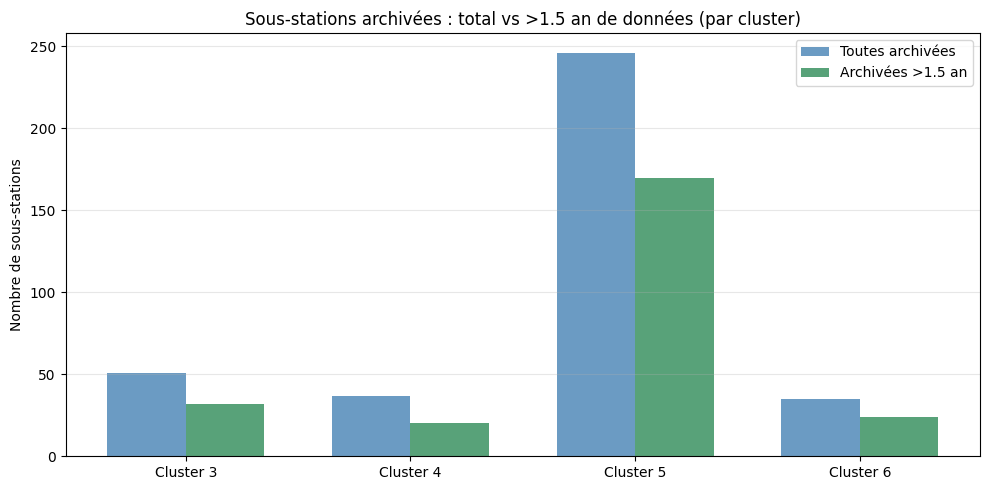

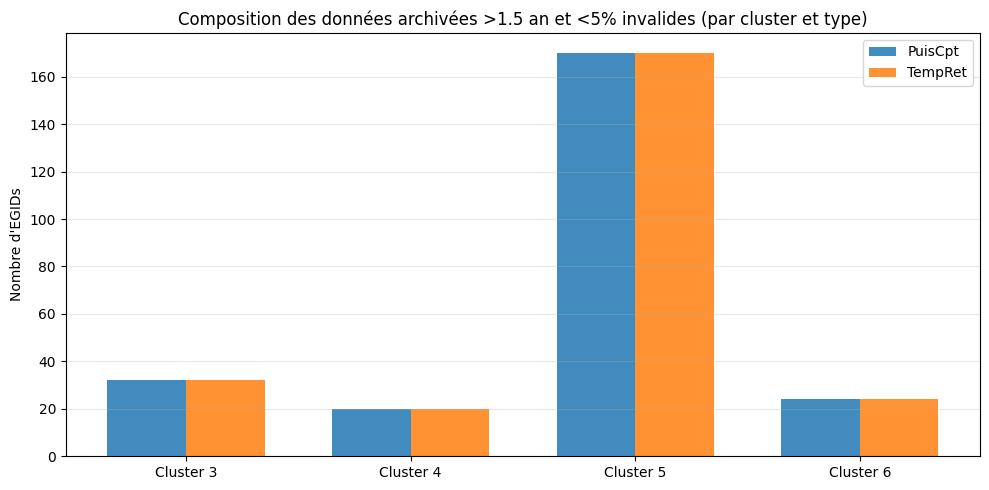

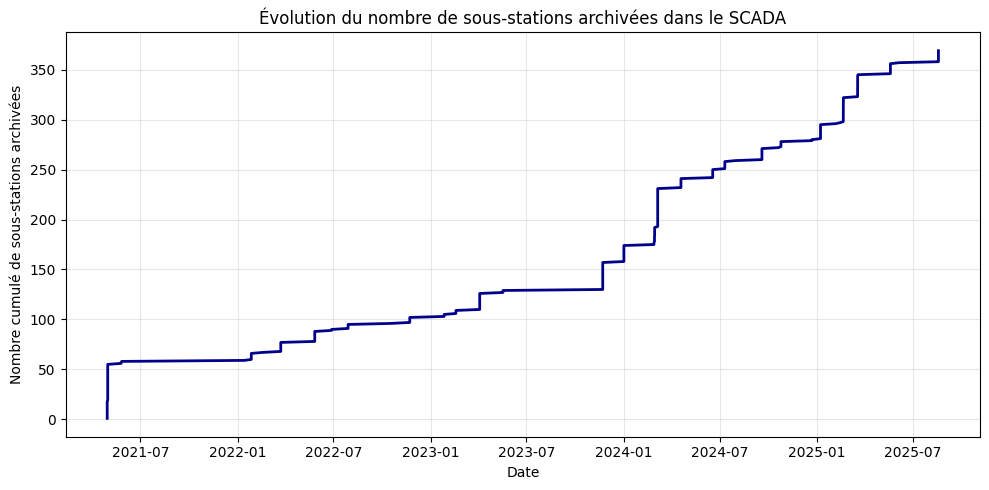

C:\Users\luandrey\AppData\Local\Temp\ipykernel_21816\895953715.py:109: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_5y["mois"] = df_5y["date"].dt.to_period("M")


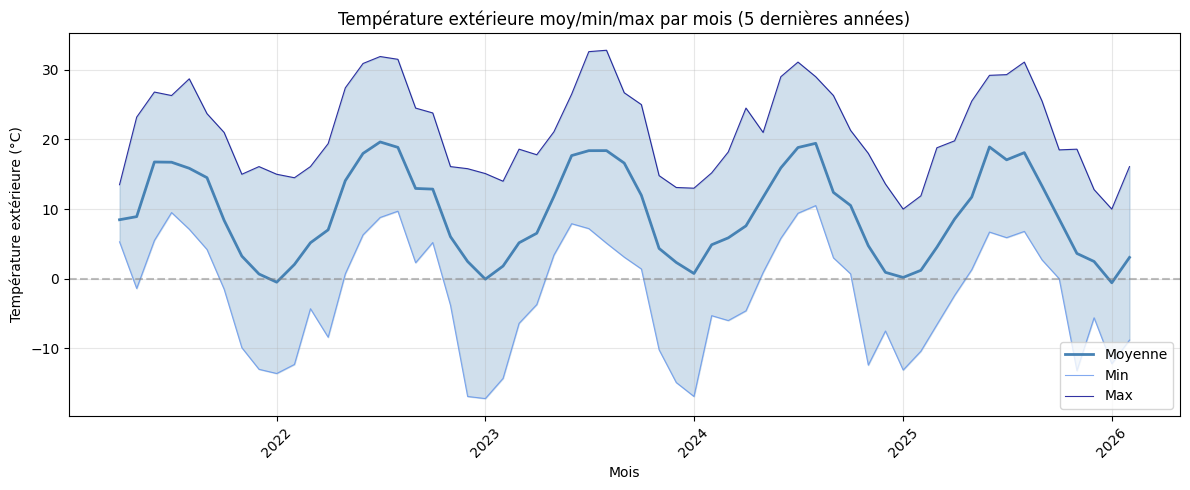

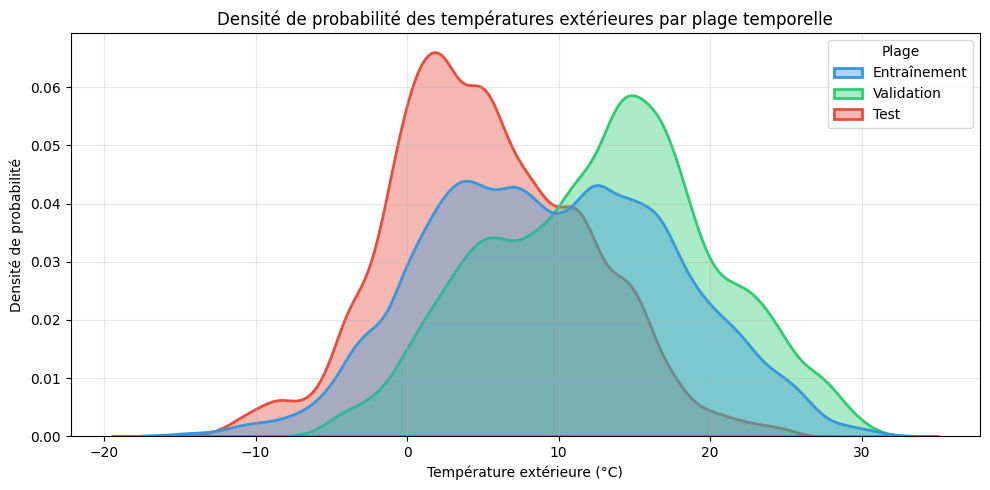

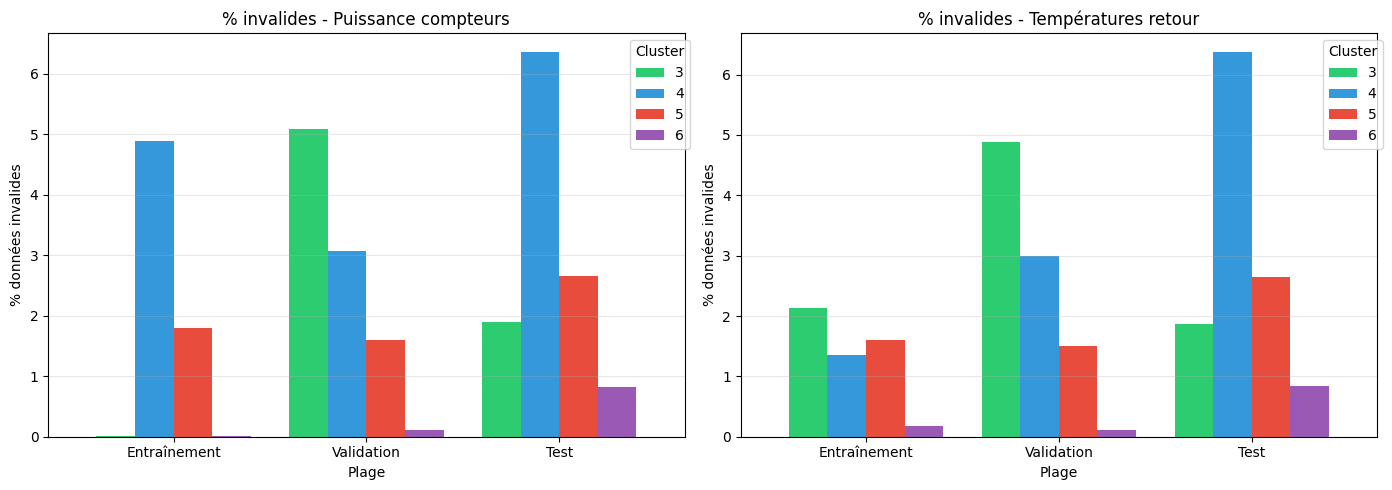

3913

In [2]:
# Section exécutable après config (1) + pipeline complet une fois (parquets générés)
if not PATH_SST_ENRICHED.exists():
    raise FileNotFoundError(
        f"Fichier requis absent : {PATH_SST_ENRICHED}. Exécuter les sections 2 à 6 au moins une fois."
    )
df_enriched = pd.read_parquet(PATH_SST_ENRICHED)
df_gis = pd.read_parquet(PATH_GIS)
df_gis["U_NO_EGID"] = df_gis["U_NO_EGID"].astype(str)
egid_to_cluster = df_gis.set_index("U_NO_EGID")["cluster"].to_dict()
valid_egids = set(egid_to_cluster.keys())

def filter_egids(df):
    df = df.copy()
    df["EGID_str"] = df["EGID"].astype(str)
    grp = df.groupby("EGID_str")
    span = grp["date"].agg(lambda x: (x.max() - x.min()).days / 365.25)
    valid_ratio = grp["inv"].apply(lambda x: (x == 0).mean())
    ok = (span >= MIN_YEARS_DATA) & (valid_ratio >= MIN_VALID_RATIO)
    return ok[ok].index.tolist()

df_f = df_enriched[df_enriched["EGID"].astype(str).isin(valid_egids)].copy()
keep_egids = filter_egids(df_f)
del df_f
gc.collect()

# Données pour les graphiques
df_archived = df_enriched[df_enriched["EGID"].astype(str).isin(valid_egids)].copy()
df_archived["cluster"] = df_archived["EGID"].astype(str).map(egid_to_cluster)
df_dates = df_enriched[["date_15min", "TempExt"]].drop_duplicates(subset=["date_15min"])

# Plages train/val/test (depuis dmax global) - convertir en UTC pour cohérence avec date_15min
def to_utc_ts(ts):
    t = pd.Timestamp(ts)
    if t.tz is None:
        return t.tz_localize("Europe/Zurich", ambiguous=True).tz_convert("UTC")
    return t.tz_convert("UTC")
dmin_g = df_enriched["date"].min()
dmax_g = df_enriched["date"].max()
dmin_g_utc, dmax_g_utc = to_utc_ts(dmin_g), to_utc_ts(dmax_g)
test_end = dmax_g_utc
test_start = dmax_g_utc - pd.DateOffset(months=TEST_MONTHS, days=TEST_EXTRA_DAYS)
val_end = test_start
val_start = dmax_g_utc - pd.DateOffset(months=VAL_MONTHS_MAX, days=VAL_EXTRA_DAYS)
train_end = val_start
train_start = dmin_g_utc

def assign_split(d):
    if test_start <= d <= test_end:
        return "Test"
    if val_start <= d < val_end:
        return "Validation"
    if train_start <= d < train_end:
        return "Entraînement"
    return None

# 1. Histogramme : part SST archivées >1.5 an vs total par cluster
fig, ax = plt.subplots(figsize=(10, 5))
clusters = sorted([int(c) for c in df_gis["cluster"].dropna().unique() if pd.notna(c)])
x = np.arange(len(clusters))
width = 0.35
total_per_cluster = [sum(1 for e in valid_egids if egid_to_cluster.get(e) == c) for c in clusters]
gt15_per_cluster = [sum(1 for e in keep_egids if egid_to_cluster.get(e) == c) for c in clusters]
ax.bar(x - width/2, total_per_cluster, width, label="Toutes archivées", color="steelblue", alpha=0.8)
ax.bar(x + width/2, gt15_per_cluster, width, label="Archivées >1.5 an", color="seagreen", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f"Cluster {int(c)}" for c in clusters])
ax.set_ylabel("Nombre de sous-stations")
ax.set_title("Sous-stations archivées : total vs >1.5 an de données (par cluster)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 1b. Composition des données archivées >1.5 an et <5% invalides (par cluster et DATA_TYPE)
df_keep = df_archived[df_archived["EGID"].astype(str).isin(keep_egids)]
comp_keep = df_keep.groupby(["cluster", "DATA_TYPE"])["EGID"].nunique().unstack(fill_value=0)
comp_keep = comp_keep.reindex(clusters).fillna(0)
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(clusters))
w = 0.35
for i, dtype in enumerate(comp_keep.columns):
    offset = (i - len(comp_keep.columns) / 2 + 0.5) * w
    ax.bar(x + offset, comp_keep[dtype], w, label=dtype, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f"Cluster {int(c)}" for c in clusters])
ax.set_ylabel("Nombre d'EGIDs")
ax.set_title("Composition des données archivées >1.5 an et <5% invalides (par cluster et type)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
del df_keep

# 2. Courbe : nombre de sous-stations archivées au cours du temps (cumul)
first_date = df_archived.groupby(df_archived["EGID"].astype(str))["date"].min().sort_values()
cumul = np.arange(1, len(first_date) + 1)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(first_date.values, cumul, linewidth=2, color="darkblue")
ax.set_xlabel("Date")
ax.set_ylabel("Nombre cumulé de sous-stations archivées")
ax.set_title("Évolution du nombre de sous-stations archivées dans le SCADA")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Courbes TempExt moy/min/max par mois (5 dernières années) avec plage min-max
df_dates["date"] = pd.to_datetime(df_dates["date_15min"])
df_5y = df_dates[df_dates["date"] >= (dmax_g_utc - pd.DateOffset(years=5))]
df_5y["mois"] = df_5y["date"].dt.to_period("M")
monthly = df_5y.groupby("mois")["TempExt"].agg(["mean", "min", "max"]).reset_index()
monthly["mois_dt"] = monthly["mois"].dt.to_timestamp()
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(monthly["mois_dt"], monthly["min"], monthly["max"], alpha=0.25, color="steelblue")
ax.plot(monthly["mois_dt"], monthly["mean"], linewidth=2, color="steelblue", label="Moyenne")
ax.plot(monthly["mois_dt"], monthly["min"], linewidth=0.8, color="cornflowerblue", alpha=0.8, label="Min")
ax.plot(monthly["mois_dt"], monthly["max"], linewidth=0.8, color="darkblue", alpha=0.8, label="Max")
ax.set_xlabel("Mois")
ax.set_ylabel("Température extérieure (°C)")
ax.set_title("Température extérieure moy/min/max par mois (5 dernières années)")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. Densité de probabilité des températures par plage train/val/test (KDE)
# Chaque plage normalisée séparément (common_norm=False) pour comparaison équitable
df_dates["split"] = df_dates["date"].apply(assign_split)
df_split = df_dates.dropna(subset=["split"])
order = ["Entraînement", "Validation", "Test"]
df_plot = df_split[df_split["split"].isin(order)].copy()
import seaborn as sns
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(
    data=df_plot, x="TempExt", hue="split", hue_order=order,
    fill=True, alpha=0.4, linewidth=2, common_norm=False,
    palette=["#3498db", "#2ecc71", "#e74c3c"],
)
ax.set_xlabel("Température extérieure (°C)")
ax.set_ylabel("Densité de probabilité")
ax.set_title("Densité de probabilité des températures extérieures par plage temporelle")
ax.grid(alpha=0.3)
leg = ax.get_legend()
if leg is not None:
    leg.set_title("Plage")
plt.tight_layout()
plt.show()

# 5. Histogramme : % données invalides par plage et par cluster (PuisCpt / TempRet)
df_archived["date_utc"] = pd.to_datetime(df_archived["date"]).dt.tz_localize("Europe/Zurich", ambiguous=True).dt.tz_convert("UTC")
dt = df_archived["date_utc"]
cond_test = (dt >= test_start) & (dt <= test_end)
cond_val = (dt >= val_start) & (dt < val_end)
cond_train = (dt >= train_start) & (dt < train_end)
df_archived["split"] = np.select([cond_test, cond_val, cond_train], ["Test", "Validation", "Entraînement"], default=None)
df_inv = df_archived.dropna(subset=["split", "cluster"])
df_inv = df_inv.copy()
df_inv["cluster"] = df_inv["cluster"].astype(int)
colors = ["#2ecc71", "#3498db", "#e74c3c", "#9b59b6"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (dtype_key, dtype_label) in zip(axes, [("PuisCpt", "Puissance compteurs"), ("TempRet", "Températures retour")]):
    df_dtype = df_inv[df_inv["DATA_TYPE"] == dtype_key]
    pct_inv = df_dtype.groupby(["split", "cluster"]).apply(
        lambda g: (g["inv"] != 0).mean() * 100
    ).unstack(fill_value=0)
    for c in clusters:
        if c not in pct_inv.columns:
            pct_inv[c] = 0.0
    pct_inv = pct_inv[[c for c in clusters]].fillna(0)
    pct_inv = pct_inv.reindex(["Entraînement", "Validation", "Test"])
    pct_inv.plot(kind="bar", ax=ax, width=0.8, color=colors, legend=True)
    ax.set_xlabel("Plage")
    ax.set_ylabel("% données invalides")
    ax.set_title(f"% invalides - {dtype_label}")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1))
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

del df_enriched, df_archived, df_dates, df_gis
gc.collect()

In [10]:
# Composition par cluster et DATA_TYPE
results = []
for split_name, folder in [("Training", PATH_TRAINING), ("Validation", PATH_VALIDATION), ("Test", PATH_TEST)]:
    for fp in folder.glob("*_transfo.parquet"):
        # Ex: cluster3_TempRet_transfo.parquet
        name = fp.stem.replace("_transfo", "")
        if "_" in name and name.startswith("cluster"):
            parts = name.split("_", 2)
            cluster_id = parts[0].replace("cluster", "")
            dtype = parts[1] if len(parts) > 1 else "?"
            df = pd.read_parquet(fp)
            # Compter les colonnes EGID.DATA_TYPE (hors Dates, TempExt, encoding)
            val_cols = [c for c in df.columns if "." in c and not c.endswith(".inv") 
                        and not c.endswith("_fc") and not c.endswith("_norm")]
            n_egid = len(set(c.split(".")[0] for c in val_cols))
            results.append({"Split": split_name, "Cluster": cluster_id, "DATA_TYPE": dtype, "EGIDs": n_egid, "Lignes": len(df)})
            del df
            gc.collect()

df_stats = pd.DataFrame(results)
print("Composition des jeux de données (EGIDs par cluster/type) :")
print(df_stats.pivot_table(index=["Cluster", "DATA_TYPE"], columns="Split", values="EGIDs", aggfunc="sum", fill_value=0).to_string())
print("\nLignes par split :")
print(df_stats.groupby("Split")[["Lignes"]].sum().to_string())

Composition des jeux de données (EGIDs par cluster/type) :
Split              Test  Training  Validation
Cluster DATA_TYPE                            
3       PuisCpt      28        28          28
        TempRet      28        28          28
4       PuisCpt      18        18          18
        TempRet      18        18          18
5       PuisCpt     103        98         100
        TempRet     103       103         103
6       PuisCpt      16        15          15
        TempRet      16        16          16

Lignes par split :
            Lignes
Split             
Test        140638
Training    562186
Validation  141342
